# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

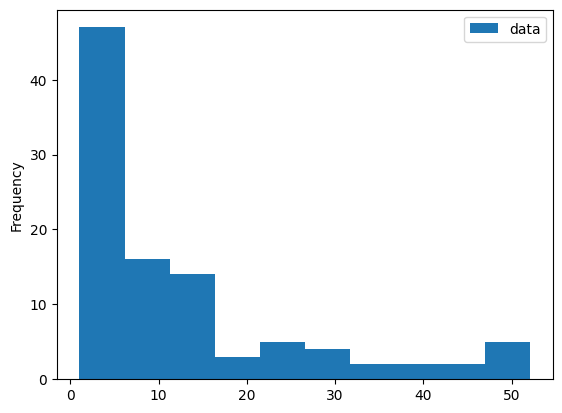

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

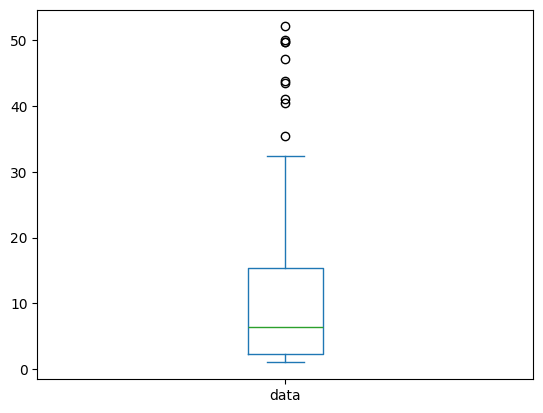

In [3]:
df.plot.box()

### Pros and Cons of the Histogram Visualization:

Pros:

* The histogram allows you to clearly see distribution of the prices: this allows you to see that there are many drugs in the $10 range. Thus, these impact the average, so it is good to have an understanding.
* The box plot better highlights irregularlies, vs. common data points. For example, we are able to see the $50 price for drugs isn't just a one off outlier as there are a few drugs that fall into this category.

Cons:

* There is no title or axis in the graph, making it harder to understand what's going on
* There is no unit of measure in the graph: is this in dollars, thousands of dollars, or euros?


### Pros and Cons of the BoxPlot Visualization:

Pros:

* The user is particularly interested in outliers of this dataset (they are interested in knowing how much the more expensive drugs cost), boxplots are great for visualizing outliers.
* The mean is clearly labeled, allowing the pharmasicists to clearly see how much more expensive these expensive drugs are than the mean drug prices.

Cons:

* There is no unit of measure in the graph: is this in dollars, thousands of dollars, or euros?
* All data points are represnted the same, so there is no way to see distribution. For example, we don't know that there are tons of drugs in the $10 range, this affects the mean which is the reason for its smaller value, but we don't deliberately get to see the distribution here.


### Which Graph I Would Choose
The goal of this graph is for the administrator of a pharmacy to know how much the more expensive drugs tend to cost, therefore, the **boxplot** is a better suited visualization because it better highlights outliers. The pharmacy administrator is interested in the more expensive drugs, which will be outliers, or just on the higher end of the graph. In terms of comparing these to what drugs tend to cost, the mean is a good metric to see what drugs tend to cost. The boxplot clearly highlights the mean, and key percentiles, such as the 25% and 75%. Therefore, looking at this graph you can clearly see how higher drugs compare to typical drug costs. The one aspect of the histogram that would have been beneficial to see if the frequency of values, such as the high concentration of drugs in the $10 range, which could help understand the mean. However, overall the boxplot better highlights the key aspects of the data we are interested in. To make this graph better and more reliable, we should add clear axis labels and a title. Additionally, we should add a unit of measure to ensure we're correctly understanding drug prices: is it $50.00 or $50,000.00. Since this metric is in terms of money, we should represent the axis ticks as such with $ and 2 decimal places. We could also lable the mean to allow viewers to quickly and easily visualize it.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [21]:
import matplotlib.pyplot as plt

In [4]:
# Load the Data and look at the first few rows

ecommerce_data = pd.read_csv("data/ecommerce_data.csv")
ecommerce_data.head()

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1/1/2020,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,1/1/2020,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,1/1/2020,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,1/1/2020,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,1/1/2020,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


In [ ]:
# Look at the summary stats of all numeric columns
ecommerce_data.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000
mean,5087.107488,56186.515097,221.381418,3.766908,0.156467,28.212340
std,2817.482266,31980.375516,585.257531,2.221776,0.207429,241.864342
min,13.000000,1841.000000,0.444000,1.000000,0.000000,-3839.990400
25%,2655.750000,27978.750000,17.018000,2.000000,0.000000,1.763200
50%,5183.500000,60472.500000,53.810000,3.000000,0.200000,8.296800
75%,7498.250000,90032.000000,205.105700,5.000000,0.200000,28.315125
max,9994.000000,99301.000000,13999.960000,14.000000,0.800000,6719.980800


## Analysis on Categorical Columns

In [9]:
# Look at the Category column to see if this is a good metric to group by
ecommerce_data['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

### Analysis By Category

In [76]:
# Make a df with only the meaningful numeric columns and the Category column for analysis
ecommerce_data_num = ecommerce_data[['Sales', 'Quantity', 'Discount', 'Profit', 'Category']]
ecommerce_data_num

,Sales,Quantity,Discount,Profit,Category
0,48.896,4,0.2,8.5568,Furniture
1,474.430,11,0.0,199.2606,Furniture
2,3.600,2,0.0,1.7280,Office Supplies
3,454.560,5,0.2,-107.9580,Office Supplies
4,141.420,5,0.6,-187.3815,Furniture
...,...,...,...,...,...
3307,90.930,7,0.0,2.7279,Technology
3308,52.776,3,0.2,19.7910,Office Supplies
3309,13.904,2,0.2,4.5188,Office Supplies
3310,20.720,2,0.2,6.4750,Office Supplies


In [79]:
# Look at all Summary Stats Grouped By Category
ecommerce_data_num.groupby('Category').describe()

Sales                                                   \
                  count        mean          std    min     25%      50%   
Category                                                                   
Furniture         686.0  313.975611   451.679254  1.892  41.960  171.288   
Office Supplies  2002.0  122.925662   354.294186  0.444  11.766   27.135   
Technology        624.0  435.466043  1051.860360  0.990  65.990  150.569   

                                     Quantity            ... Discount       \
                      75%        max    count      mean  ...      75%  max   
Category                                                 ...                 
Furniture        381.9435   4416.174    686.0  3.552478  ...      0.2  0.7   
Office Supplies   83.7100   5443.960   2002.0  3.834166  ...      0.2  0.8   
Technology       409.5530  13999.960    624.0  3.786859  ...      0.2  0.7   

                 Profit                                                        \
                  count       mean         std        min        25%      50%   
Category                                                                        
Furniture         686.0   4.399987  123.801918 -1002.7836 -13.752675   6.8726   
Office Supplies  2002.0  19.848462  155.502587 -2929.4845   2.088225   6.6793   
Technology        624.0  81.224770  461.208152 -3839.9904   5.794075  22.4102   

                                      
                      75%        max  
Category                              
Furniture        28.42985   609.7157  
Office Supplies  20.57640  2504.2216  
Technology       66.77505  6719.9808  

[3 rows x 32 columns]

In [77]:
# Find the mean of Sales, Quantity, Discount, and Profit Grouped By Category
ecommerce_data_num.groupby('Category').mean()

,Sales,Quantity,Discount,Profit
Category,,,,
Furniture,313.975611,3.552478,0.169854,4.399987
Office Supplies,122.925662,3.834166,0.160040,19.848462
Technology,435.466043,3.786859,0.130288,81.224770


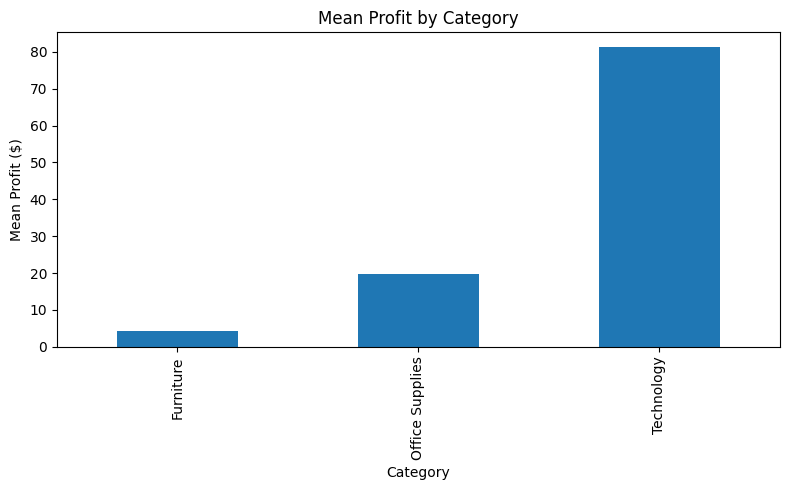

In [59]:
# Plot the mean Profit for each Category
mean_profit = ecommerce_data_num.groupby('Category')['Profit'].mean() 
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar') 
plt.title("Mean Profit by Category") 
plt.xlabel("Category") 
plt.ylabel("Mean Profit ($)") 
plt.tight_layout() 
plt.show()

In [60]:
# Find the median of Sales, Quantity, Discount, and Profit Grouped By Category
ecommerce_data_num.groupby('Category').median()

,Sales,Quantity,Discount,Profit
Category,,,,
Furniture,171.288,3.0,0.2,6.8726
Office Supplies,27.135,3.0,0.0,6.6793
Technology,150.569,3.0,0.2,22.4102


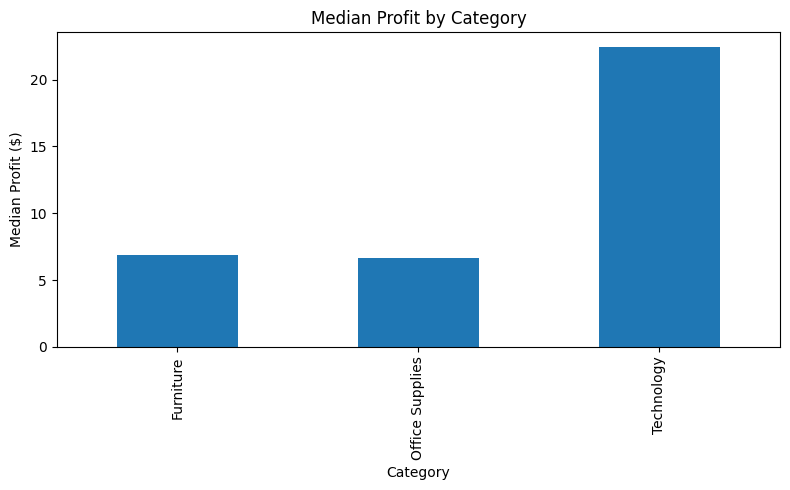

In [61]:
# Plot the median Profit for each Category
median_profit = ecommerce_data_num.groupby('Category')['Profit'].median() 
plt.figure(figsize=(8,5)) 
median_profit.plot(kind='bar') 
plt.title("Median Profit by Category") 
plt.xlabel("Category") 
plt.ylabel("Median Profit ($)") 
plt.tight_layout() 
plt.show()

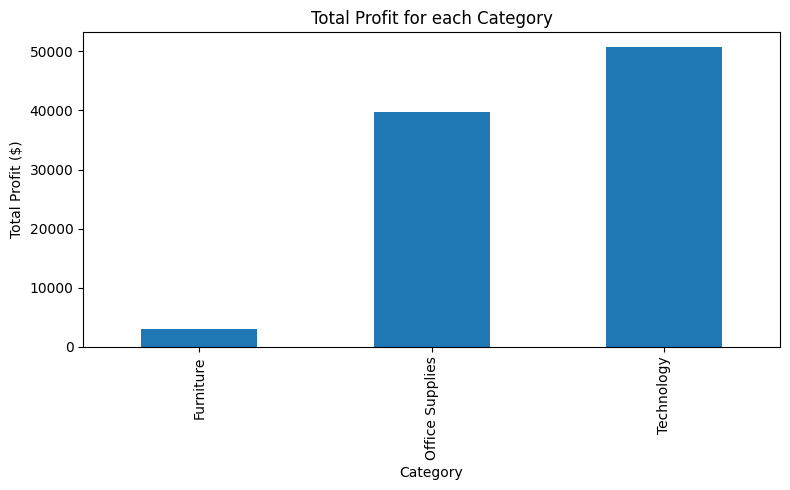

In [78]:
# Plot the Total Profit for each Category
mean_profit = ecommerce_data_num.groupby('Category')['Profit'].sum()
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar') 
plt.title("Total Profit for each Category") 
plt.xlabel("Category") 
plt.ylabel("Total Profit ($)") 
plt.tight_layout() 
plt.show()

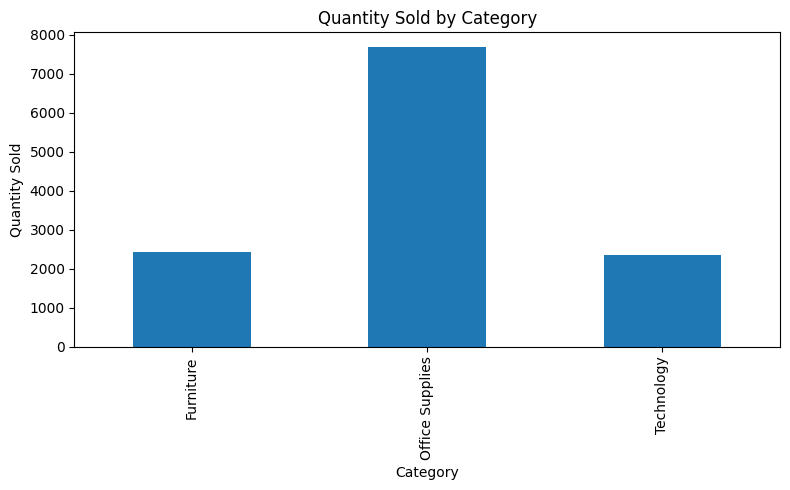

In [ ]:
# Plot the Total Quantity Sold each Category
mean_profit = ecommerce_data_num.groupby('Category')['Quantity'].sum()
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar') 
plt.title("Total Quantity Sold by Category") 
plt.xlabel("Category") 
plt.ylabel("Total Quantity Sold") 
plt.tight_layout() 
plt.show()

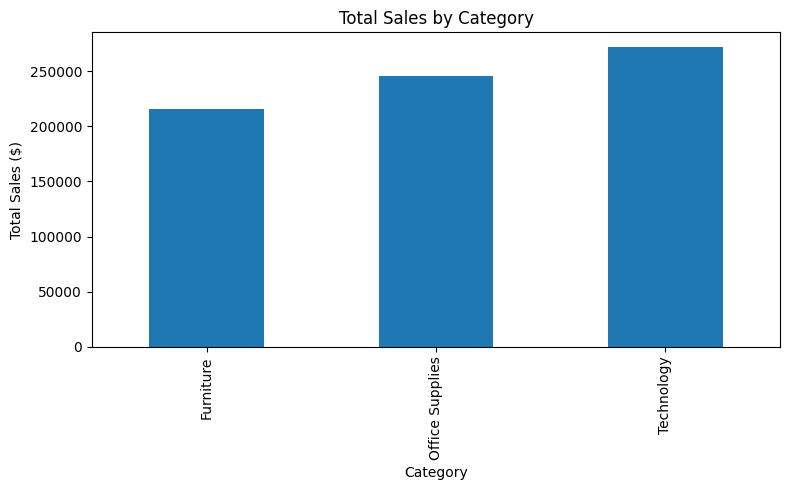

In [66]:
# Plot the Total Sales for each Category
mean_profit = ecommerce_data_num.groupby('Category')['Sales'].sum()
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar') 
plt.title("Total Sales by Category") 
plt.xlabel("Category") 
plt.ylabel("Total Sales ($)") 
plt.tight_layout() 
plt.show()

### Analysis By Region

In [24]:
# Look at the Region column to see if this is a good metric to group by
ecommerce_data['Region'].unique()

array(['East', 'West', 'Central', 'South'], dtype=object)

In [80]:
# Make a df with only the meaningful numeric columns and the Region column for analysis
ecommerce_data_num = ecommerce_data[['Sales', 'Quantity', 'Discount', 'Profit', 'Region']]
ecommerce_data_num

,Sales,Quantity,Discount,Profit,Region
0,48.896,4,0.2,8.5568,East
1,474.430,11,0.0,199.2606,West
2,3.600,2,0.0,1.7280,Central
3,454.560,5,0.2,-107.9580,Central
4,141.420,5,0.6,-187.3815,Central
...,...,...,...,...,...
3307,90.930,7,0.0,2.7279,East
3308,52.776,3,0.2,19.7910,East
3309,13.904,2,0.2,4.5188,West
3310,20.720,2,0.2,6.4750,West


In [81]:
# Look at all Summary Stats Grouped By Region
ecommerce_data_num.groupby('Region').describe()

Sales                                                            \
          count        mean         std    min      25%     50%       75%   
Region                                                                      
Central   778.0  189.072144  417.895423  0.444  14.2680  43.391  181.9545   
East      921.0  231.360374  682.147309  1.188  17.1200  51.336  195.6400   
South     518.0  237.269995  566.771947  1.584  16.9545  50.707  232.6400   
West     1095.0  228.427731  607.048879  0.990  19.4400  66.960  204.4665   

                   Quantity            ... Discount       Profit             \
               max    count      mean  ...      75%  max   count       mean   
Region                                 ...                                    
Central   5443.960    778.0  3.701799  ...      0.3  0.8   778.0   9.705455   
East     11199.968    921.0  3.703583  ...      0.2  0.7   921.0  36.080957   
South     7999.980    518.0  3.696911  ...      0.2  0.7   518.0  17.082834   
West     13999.960   1095.0  3.899543  ...      0.2  0.7  1095.0  40.008179   

                                                                       
                std        min      25%      50%       75%        max  
Region                                                                 
Central  206.972463 -2929.4845 -5.79730   5.0617  21.06725  2504.2216  
East     250.115322 -1049.3406  1.70240   8.0406  27.28620  5039.9856  
South    235.677651 -3839.9904  1.38090   7.2576  28.59810  1439.9760  
West     259.365618 -3399.9800  4.09145  10.8682  34.16220  6719.9808  

[4 rows x 32 columns]

In [41]:
# Find the mean of Sales, Quantity, Discount, and Profit Grouped By Region
ecommerce_data_num.groupby('Region').mean()

,Sales,Quantity,Discount,Profit
Region,,,,
Central,189.072144,3.701799,0.239614,9.705455
East,231.360374,3.703583,0.147774,36.080957
South,237.269995,3.696911,0.155405,17.082834
West,228.427731,3.899543,0.105205,40.008179


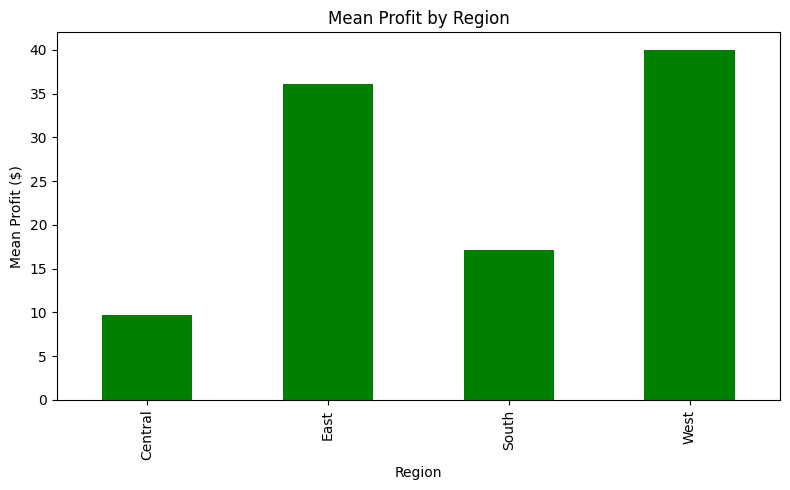

In [44]:
# Plot the mean Profit for each Region
mean_profit = ecommerce_data_num.groupby('Region')['Profit'].mean() 
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar', color='green') 
plt.title("Mean Profit by Region") 
plt.xlabel("Region") 
plt.ylabel("Mean Profit ($)") 
plt.tight_layout() 
plt.show()

In [45]:
# Find the median of Sales, Quantity, Discount, and Profit Grouped By Region
ecommerce_data_num.groupby('Region').median()

,Sales,Quantity,Discount,Profit
Region,,,,
Central,43.391,3.0,0.2,5.0617
East,51.336,3.0,0.0,8.0406
South,50.707,3.0,0.2,7.2576
West,66.960,3.0,0.0,10.8682


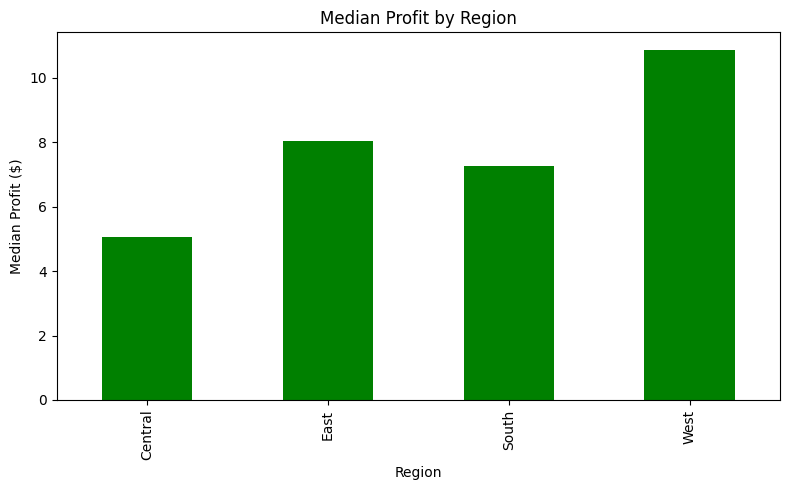

In [46]:
# Plot the median Profit for each Region
median_profit = ecommerce_data_num.groupby('Region')['Profit'].median() 
plt.figure(figsize=(8,5)) 
median_profit.plot(kind='bar', color='green') 
plt.title("Median Profit by Region") 
plt.xlabel("Region") 
plt.ylabel("Median Profit ($)") 
plt.tight_layout() 
plt.show()

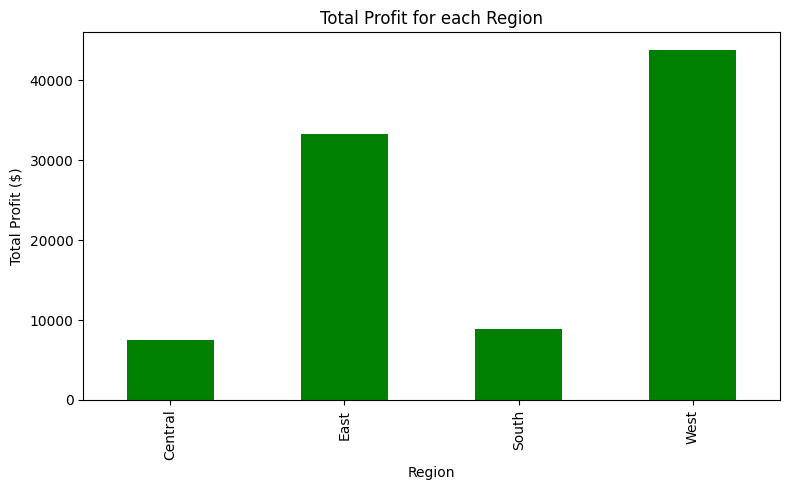

In [82]:
# Plot the Total Profit for each Region
mean_profit = ecommerce_data_num.groupby('Region')['Profit'].sum()
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar', color='green') 
plt.title("Total Profit for each Region") 
plt.xlabel("Region") 
plt.ylabel("Total Profit ($)") 
plt.tight_layout() 
plt.show()

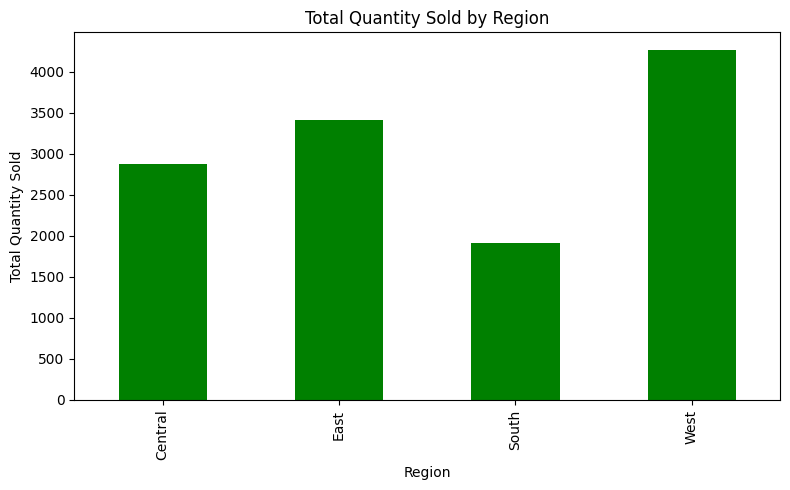

In [69]:
# Plot the Total Quantity Sold each Region
mean_profit = ecommerce_data_num.groupby('Region')['Quantity'].sum()
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar', color='green') 
plt.title("Total Quantity Sold by Region") 
plt.xlabel("Region") 
plt.ylabel("Total Quantity Sold") 
plt.tight_layout() 
plt.show()

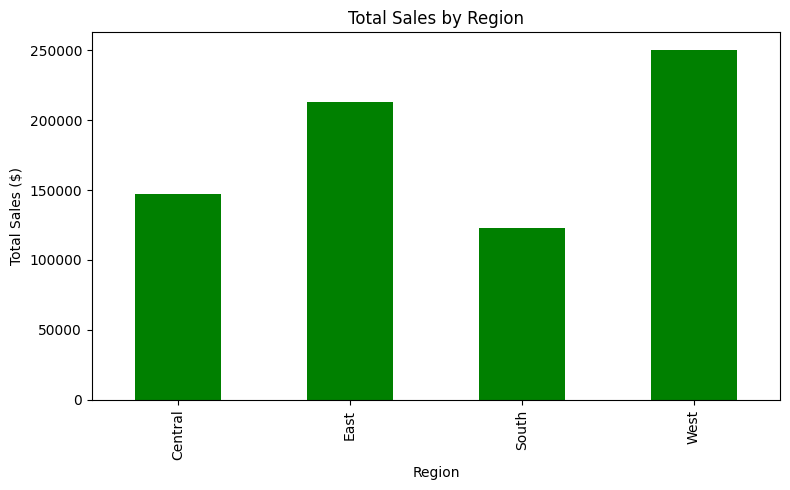

In [71]:
# Plot the Total Sales for each Region
mean_profit = ecommerce_data_num.groupby('Region')['Sales'].sum()
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar', color='green') 
plt.title("Total Sales by Region") 
plt.xlabel("Region") 
plt.ylabel("Total Sales ($)") 
plt.tight_layout() 
plt.show()

### Analysis By Segment

In [31]:
# Look at the Segment column to see if this is a good metric to group by
ecommerce_data['Segment'].unique()

array(['Consumer', 'Home Office', 'Corporate'], dtype=object)

In [83]:
# Make a df with only the meaningful numeric columns and the Segment column for analysis
ecommerce_data_num = ecommerce_data[['Sales', 'Quantity', 'Discount', 'Profit', 'Segment']]
ecommerce_data_num

,Sales,Quantity,Discount,Profit,Segment
0,48.896,4,0.2,8.5568,Consumer
1,474.430,11,0.0,199.2606,Consumer
2,3.600,2,0.0,1.7280,Home Office
3,454.560,5,0.2,-107.9580,Consumer
4,141.420,5,0.6,-187.3815,Consumer
...,...,...,...,...,...
3307,90.930,7,0.0,2.7279,Consumer
3308,52.776,3,0.2,19.7910,Consumer
3309,13.904,2,0.2,4.5188,Corporate
3310,20.720,2,0.2,6.4750,Corporate


In [84]:
# Look at all Summary Stats Grouped By Segment
ecommerce_data_num.groupby('Segment').describe()

Sales                                                            \
              count        mean         std    min      25%     50%       75%   
Segment                                                                         
Consumer     1668.0  198.983633  586.047572  0.444  16.4900  51.288  183.5210   
Corporate     980.0  246.783494  562.179524  0.556  17.8650  58.212  219.9914   
Home Office   664.0  240.154715  614.626591  0.990  16.9725  53.120  219.5640   

                       Quantity            ... Discount       Profit  \
                   max    count      mean  ...      75%  max   count   
Segment                                    ...                         
Consumer     13999.960   1668.0  3.766187  ...      0.2  0.8  1668.0   
Corporate     7999.980    980.0  3.834694  ...      0.2  0.8   980.0   
Home Office  11199.968    664.0  3.668675  ...      0.2  0.8   664.0   

                                                                           \
                  mean         std        min       25%     50%       75%   
Segment                                                                     
Consumer     27.319088  247.061427 -2287.7820  1.734325  7.7982  26.75250   
Corporate    27.328942  219.615966 -3839.9904  2.337600  8.7547  31.48950   
Home Office  31.760041  259.674655 -3399.9800  1.325300  8.4945  28.76535   

                        
                   max  
Segment                 
Consumer     6719.9808  
Corporate    1906.4850  
Home Office  3919.9888  

[3 rows x 32 columns]

In [48]:
# Find the mean of Sales, Quantity, Discount, and Profit Grouped By Segment
ecommerce_data_num.groupby('Segment').mean()

,Sales,Quantity,Discount,Profit
Segment,,,,
Consumer,198.983633,3.766187,0.158345,27.319088
Corporate,246.783494,3.834694,0.157837,27.328942
Home Office,240.154715,3.668675,0.149729,31.760041


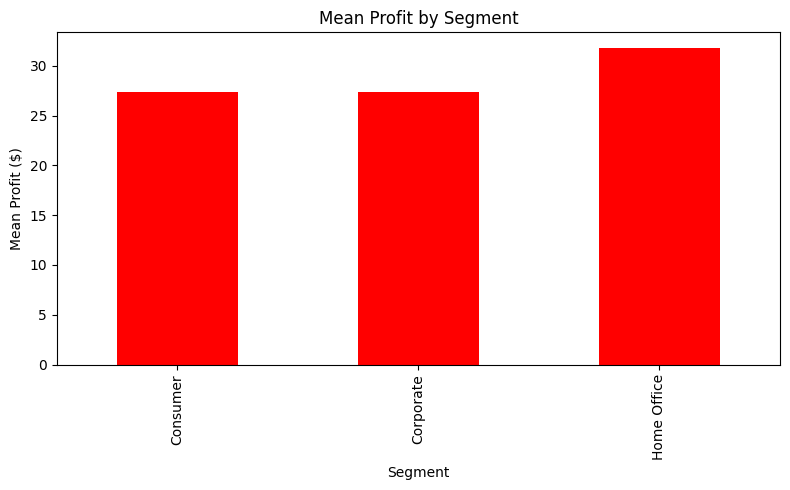

In [49]:
# Plot the mean Profit for each Segment
mean_profit = ecommerce_data_num.groupby('Segment')['Profit'].mean() 
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar', color='red') 
plt.title("Mean Profit by Segment") 
plt.xlabel("Segment") 
plt.ylabel("Mean Profit ($)") 
plt.tight_layout() 
plt.show()

In [50]:
# Find the median of Sales, Quantity, Discount, and Profit Grouped By Segment
ecommerce_data_num.groupby('Segment').median()

,Sales,Quantity,Discount,Profit
Segment,,,,
Consumer,51.288,3.0,0.2,7.7982
Corporate,58.212,3.0,0.2,8.7547
Home Office,53.120,3.0,0.0,8.4945


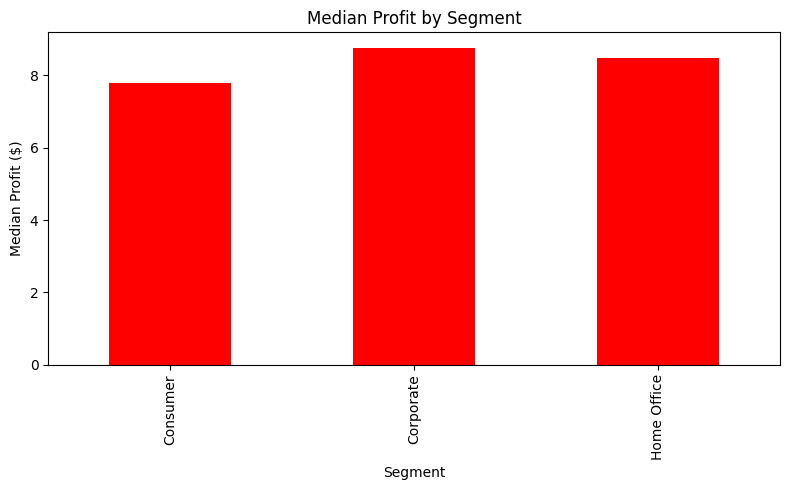

In [51]:
# Plot the median Profit for each Segment
median_profit = ecommerce_data_num.groupby('Segment')['Profit'].median() 
plt.figure(figsize=(8,5)) 
median_profit.plot(kind='bar', color='red') 
plt.title("Median Profit by Segment") 
plt.xlabel("Segment") 
plt.ylabel("Median Profit ($)") 
plt.tight_layout() 
plt.show()

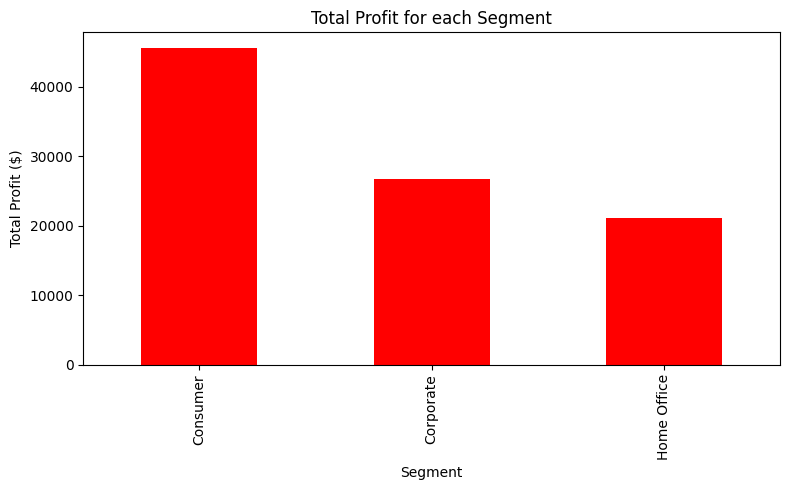

In [85]:
# Plot the Total Profit for each Segment
mean_profit = ecommerce_data_num.groupby('Segment')['Profit'].sum()
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar', color='red') 
plt.title("Total Profit for each Segment") 
plt.xlabel("Segment") 
plt.ylabel("Total Profit ($)") 
plt.tight_layout() 
plt.show()

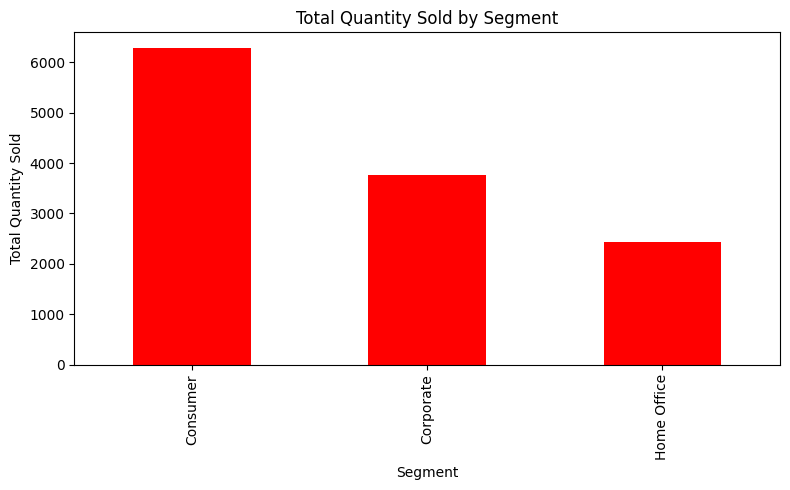

In [73]:
# Plot the Total Quantity Sold each Segment
mean_profit = ecommerce_data_num.groupby('Segment')['Quantity'].sum()
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar', color='red') 
plt.title("Total Quantity Sold by Segment") 
plt.xlabel("Segment") 
plt.ylabel("Total Quantity Sold") 
plt.tight_layout() 
plt.show()

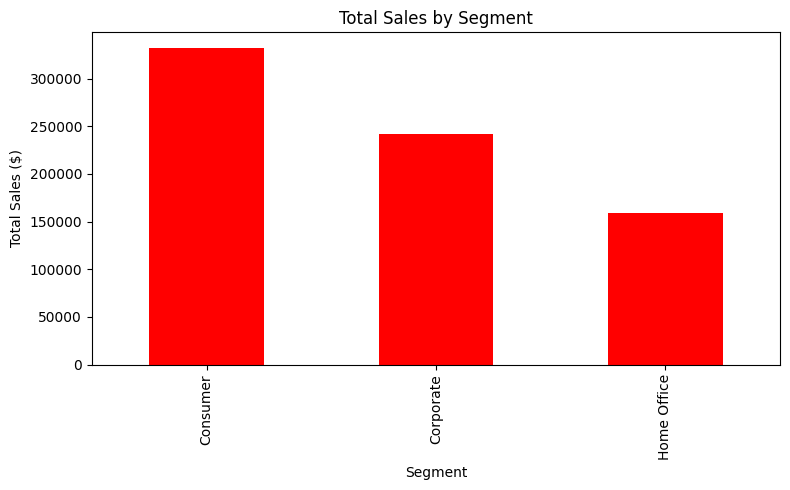

In [74]:
# Plot the Total Sales for each Segment
mean_profit = ecommerce_data_num.groupby('Segment')['Sales'].sum()
plt.figure(figsize=(8,5)) 
mean_profit.plot(kind='bar', color='red') 
plt.title("Total Sales by Segment") 
plt.xlabel("Segment") 
plt.ylabel("Total Sales ($)") 
plt.tight_layout() 
plt.show()

## Looking at Quantity, Sales, Profit, over time

In [86]:
# Make a df with only the meaningful numeric columns and the Order Date column for analysis
ecommerce_data_num = ecommerce_data[['Sales', 'Quantity', 'Discount', 'Profit', 'Order Date']]
ecommerce_data_num

,Sales,Quantity,Discount,Profit,Order Date
0,48.896,4,0.2,8.5568,1/1/2020
1,474.430,11,0.0,199.2606,1/1/2020
2,3.600,2,0.0,1.7280,1/1/2020
3,454.560,5,0.2,-107.9580,1/1/2020
4,141.420,5,0.6,-187.3815,1/1/2020
...,...,...,...,...,...
3307,90.930,7,0.0,2.7279,30-12-20
3308,52.776,3,0.2,19.7910,30-12-20
3309,13.904,2,0.2,4.5188,30-12-20
3310,20.720,2,0.2,6.4750,30-12-20


In [89]:
ecommerce_data_num['Order Date'] = pd.to_datetime(ecommerce_data_num['Order Date'], "%d%m%Y")

AssertionError: 

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

In [6]:
# Plotting the Secondary y-axis plot from page 53 of Storytelling with Data
import matplotlib.pyplot as plt

In [7]:
# Generating Fake data
sales_data = [
    {"Year": 2013, "Quarter": "Q1", "Revenue_Millions": 52.0, "Sales_Employees": 130},
    {"Year": 2013, "Quarter": "Q2", "Revenue_Millions": 56.5, "Sales_Employees": 138},
    {"Year": 2013, "Quarter": "Q3", "Revenue_Millions": 61.0, "Sales_Employees": 145},
    {"Year": 2013, "Quarter": "Q4", "Revenue_Millions": 72.0, "Sales_Employees": 155},
    {"Year": 2014, "Quarter": "Q1", "Revenue_Millions": 58.0, "Sales_Employees": 150},
    {"Year": 2014, "Quarter": "Q2", "Revenue_Millions": 62.0, "Sales_Employees": 158},
    {"Year": 2014, "Quarter": "Q3", "Revenue_Millions": 67.5, "Sales_Employees": 166},
    {"Year": 2014, "Quarter": "Q4", "Revenue_Millions": 80.0, "Sales_Employees": 178},
]

sales_df = pd.DataFrame(sales_data)
sales_df

,Year,Quarter,Revenue_Millions,Sales_Employees
0,2013,Q1,52.0,130
1,2013,Q2,56.5,138
2,2013,Q3,61.0,145
3,2013,Q4,72.0,155
4,2014,Q1,58.0,150
5,2014,Q2,62.0,158
6,2014,Q3,67.5,166
7,2014,Q4,80.0,178


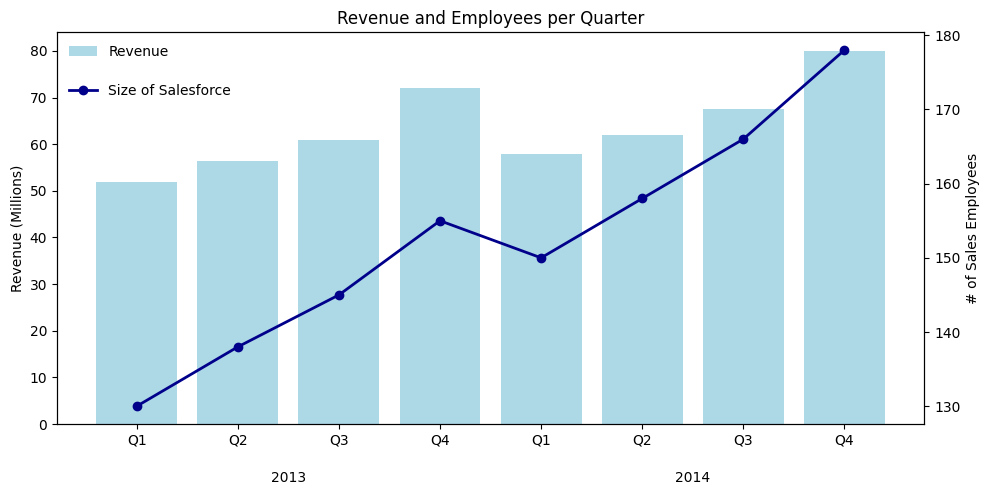

''

In [8]:

x = range(len(sales_df))

fig, ax1 = plt.subplots(figsize=(10, 5))

# --- Bars (Revenue) ---
ax1.bar(x, sales_df["Revenue_Millions"], color="lightblue", label='Revenue')
ax1.set_ylabel("Revenue (Millions)")

# --- Line (Employees) ---
ax2 = ax1.twinx()
ax2.plot(x, sales_df["Sales_Employees"], color="darkblue", marker="o", linewidth=2, label='Size of Salesforce')
ax2.set_ylabel("# of Sales Employees")

# --- Plot the legend ---
ax1.legend(loc="upper left", bbox_to_anchor=(0, 1.00), frameon=False)
ax2.legend(loc="upper left", bbox_to_anchor=(0, 0.90), frameon=False)

# --- X-axis labels ---
ax1.set_xticks(x)
ax1.set_xticklabels(sales_df["Quarter"])
plt.subplots_adjust(bottom=0.18)
ax = ax1
y_offset = -0.12
ax.text(1.5, y_offset, "2013", ha="center", va="top", transform=ax.get_xaxis_transform())
ax.text(5.5, y_offset, "2014", ha="center", va="top", transform=ax.get_xaxis_transform())



plt.title("Revenue and Employees per Quarter")
plt.tight_layout()
plt.show()

;